# HW4: Credit Card Fraud- Energy, emissions, and GDP

**Author:** Your name goes here  
**Date:** 2026-03-12


In [ ]:
pip install highlight_text wbgapi country_converter

In [2]:
import pandas as pd
import pandas_datareader.data as web  # To get data from FRED, https://fredaccount.stlouisfed.org/public/datalist/843
from bs4 import BeautifulSoup  # To parse HTML 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from highlight_text import fig_text
from matplotlib.ticker import FuncFormatter
import wbgapi as wb
import requests
import io
# For standardized country codes and continent names
import country_converter as coco
from datetime import datetime
import warnings

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Set seaborn style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)


# To avoid SSL errors
import urllib.request
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:,.2f}'.format)

# Exploring credit card fraud

We will be using a dataset with credit card transactions containing legitimate and fraud transactions. Fraud is typically well below 1% of all transactions, so a naive model that predicts that all transactions are legitimate and not fraudulent would have an accuracy of well over 99%-- pretty good, no? (well, not quite as we will see later in the course)

You can read more on credit card fraud on [Credit Card Fraud Detection Using Weighted Support Vector Machine](https://www.scirp.org/journal/paperinformation.aspx?paperid=105944)

## Obtain the data

In [ ]:
card_fraud = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/card_fraud.csv", parse_dates=["trans_date_trans_time", "dob"])


card_fraud.info()
card_fraud.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671028 entries, 0 to 671027
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   trans_date_trans_time  671028 non-null  datetime64[ns, UTC]
 1   trans_year             671028 non-null  int64              
 2   category               671028 non-null  object             
 3   amt                    671028 non-null  float64            
 4   city                   671028 non-null  object             
 5   state                  671028 non-null  object             
 6   lat                    671028 non-null  float64            
 7   long                   671028 non-null  float64            
 8   city_pop               671028 non-null  int64              
 9   job                    671028 non-null  object             
 10  dob                    671028 non-null  datetime64[ns]     
 11  merch_lat              671028 non-null 

,trans_date_trans_time,trans_year,category,amt,city,state,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,2019-02-22 07:32:58+00:00,2019,entertainment,7.79,Veedersburg,IN,40.12,-87.26,4049,"Development worker, community",1959-10-19,39.42,-87.53,0
1,2019-02-16 15:07:20+00:00,2019,kids_pets,3.89,Holloway,OH,40.01,-80.97,128,Child psychotherapist,1946-04-03,39.75,-81.52,0
2,2019-12-27 22:25:34+00:00,2019,personal_care,8.43,Arnold,MO,38.43,-90.39,35439,Land/geomatics surveyor,1985-03-31,37.73,-91.37,0
3,2019-03-03 10:11:39+00:00,2019,grocery_net,40.00,Apison,TN,35.01,-85.02,3730,Occupational therapist,1991-01-28,34.53,-84.11,0
4,2019-02-09 17:14:54+00:00,2019,food_dining,54.04,Red Cliff,CO,39.46,-106.39,277,Human resources officer,1985-04-03,39.95,-106.88,0


## How likely are fraudulent transactions?

Generate a table that summarizes the number and frequency of fraudulent transactions per year.

In [3]:
(
    card_fraud
    .assign(trans_year=lambda df: df["trans_date_trans_time"].dt.year)
    .groupby(["trans_year", "is_fraud"])
    .size()
    .reset_index(name="n")
    .assign(
        total_year=lambda df: df.groupby("trans_year")["n"].transform("sum"),
        frequency=lambda df: df["n"] / df["total_year"],
    )
    # now filter to fraud rows but total_year is still the total for that year
    .pipe(lambda df: df[df["is_fraud"] == 1])
    .style.format({"frequency": "{:.3%}"})
)

,trans_year,is_fraud,n,total_year,frequency
1,2019,1,2721,478646,0.568%
3,2020,1,1215,192382,0.632%


## How much money are fraudulent transactions costing?

Generate a table that summarizes the total amount of legitimate and fraudulent transactions per year and calculate the % of fraudulent transactions in USD terms.

In [4]:
(
    card_fraud
    .assign(trans_year=lambda df: df["trans_date_trans_time"].dt.year)
    .groupby(["trans_year", "is_fraud"])["amt"]
    .sum()
    .reset_index(name="total_amt")
    .assign(
        pct_of_year=lambda df: df.groupby("trans_year")["total_amt"].transform(lambda x: x / x.sum())
    )
    .style.format({"total_amt": "${:,.2f}", "pct_of_year": "{:.4%}"})
)

,trans_year,is_fraud,total_amt,pct_of_year
0,2019,0,"$32,182,901.19",95.7652%
1,2019,1,"$1,423,140.01",4.2348%
2,2020,0,"$12,925,913.99",95.1984%
3,2020,1,"$651,949.18",4.8016%


## Distribution of transaction amounts

Generate a histogram that shows the distribution of amounts charged to credit card, both for legitimate and fraudulent accounts. Also calculate summary statistics for both.

In [5]:
# Summary statistics by fraud status
(
    card_fraud
    .assign(fraud_label=lambda df: df["is_fraud"].map({0: "Legitimate", 1: "Fraudulent"}))
    .groupby("fraud_label")["amt"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
fraud_label,,,,,,,,
Fraudulent,"3,936.00",527.21,391.29,1.06,240.49,368.83,900.95,"1,334.07"
Legitimate,"667,092.00",67.62,155.29,1.00,9.60,47.17,82.41,"27,119.77"


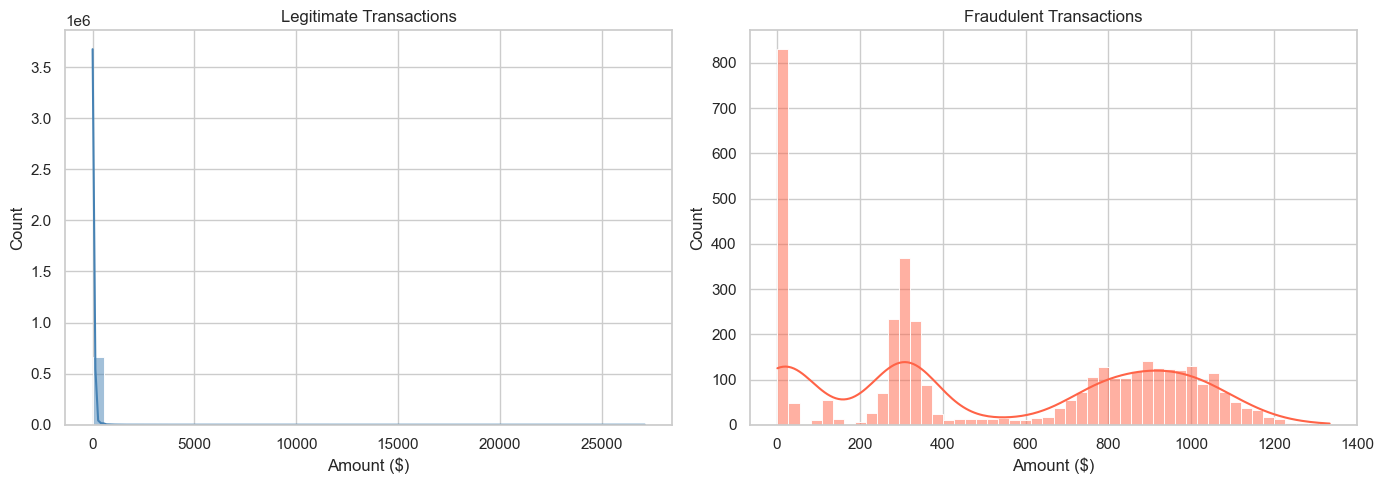

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False, sharey=False)

sns.histplot(
    card_fraud.query("is_fraud == 0")["amt"],
    bins=50, kde=True, ax=axes[0], color="steelblue"
)
axes[0].set_title("Legitimate Transactions")
axes[0].set_xlabel("Amount ($)")

sns.histplot(
    card_fraud.query("is_fraud == 1")["amt"],
    bins=50, kde=True, ax=axes[1], color="tomato"
)
axes[1].set_title("Fraudulent Transactions")
axes[1].set_xlabel("Amount ($)")

plt.tight_layout()
plt.show()

## What types of purchases are most likely to be fraud?

Consider category of merchants and produce a bar chart that shows % of total fraudulent transactions sorted in order.

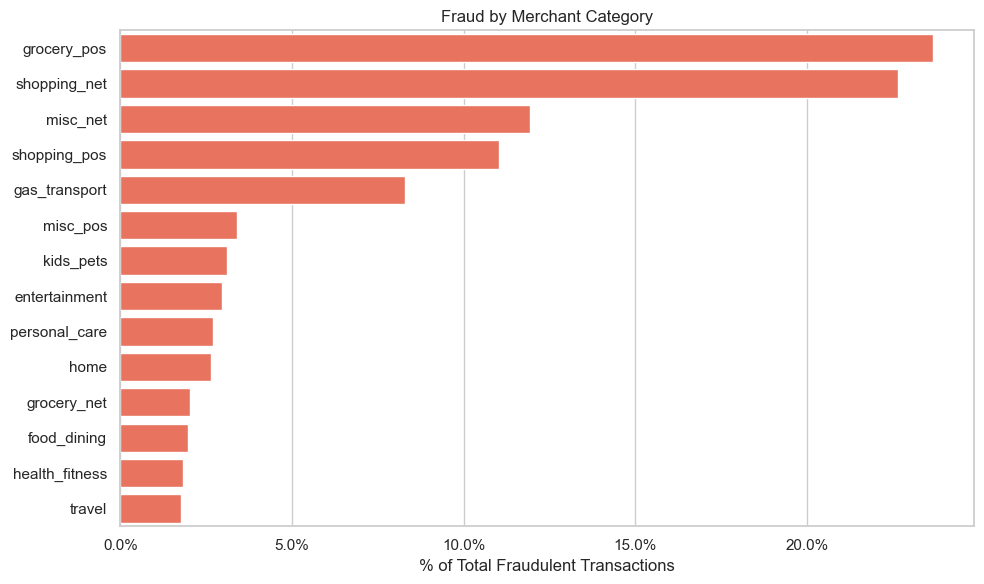

In [6]:
fraud_by_cat = (
    card_fraud
    .query("is_fraud == 1")
    .groupby("category")
    .size()
    .reset_index(name="fraud_count")
    .assign(pct=lambda df: df["fraud_count"] / df["fraud_count"].sum())
    .sort_values("pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=fraud_by_cat,
    y="category",
    x="pct",
    color="tomato",
    ax=ax
)
ax.set_xlabel("% of Total Fraudulent Transactions")
ax.set_ylabel("")
ax.set_title("Fraud by Merchant Category")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

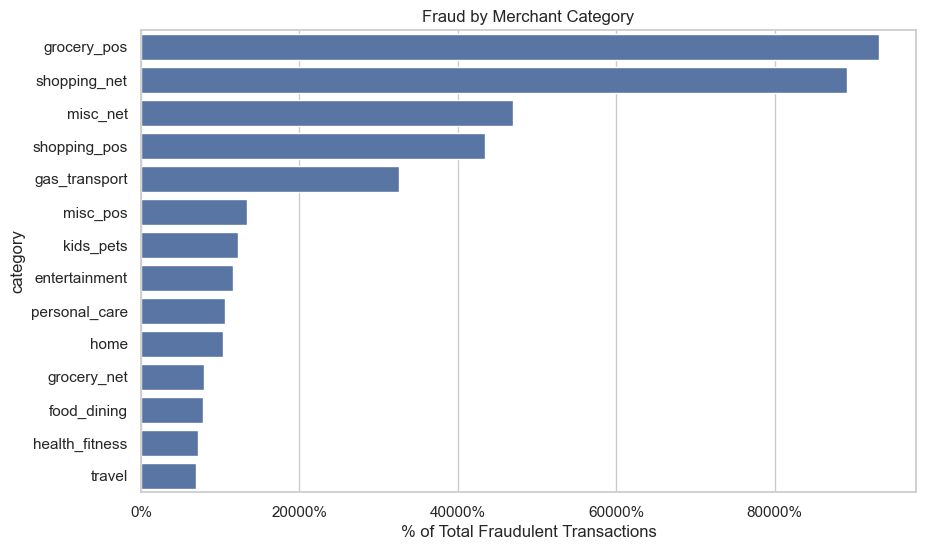

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(
    data=card_fraud.query("is_fraud == 1"),
    y="category",
    order=fraud_by_cat["category"],  # preserves your sort order
    ax=ax
)
ax.set_xlabel("% of Total Fraudulent Transactions")
ax.set_title("Fraud by Merchant Category")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))


## When is fraud more prevalent?

Which days, months, hours?

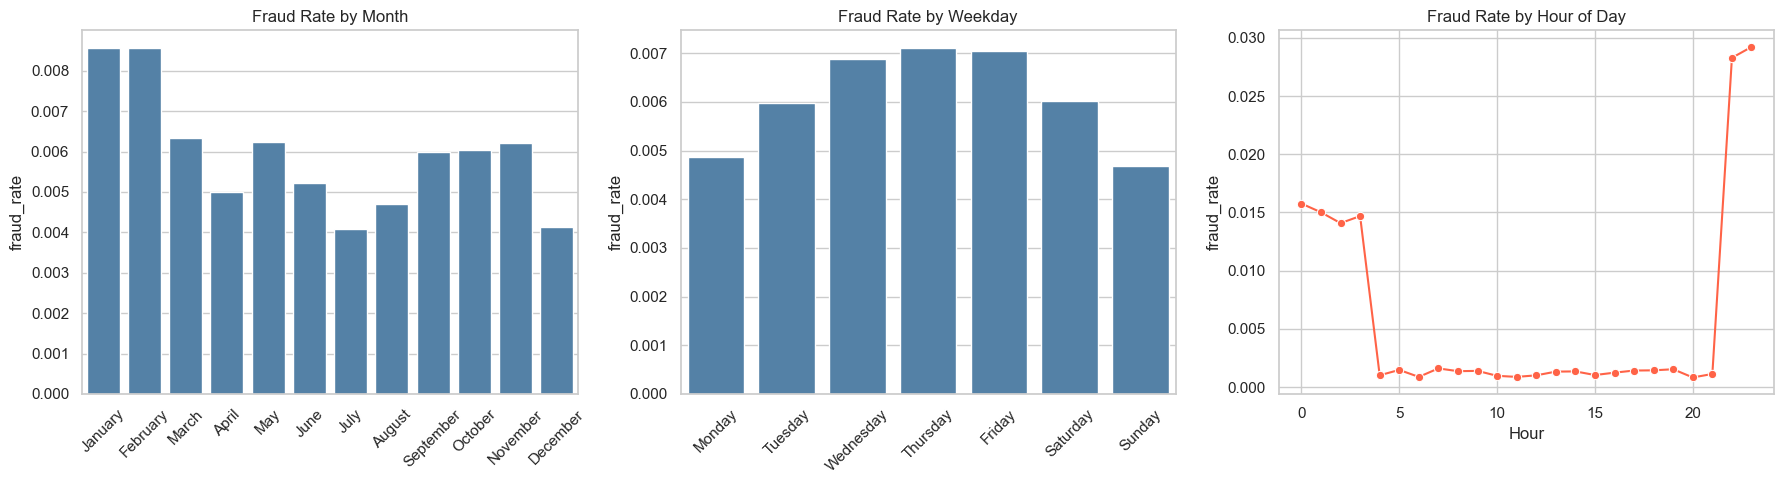

In [8]:
card_fraud_time = (
    card_fraud
    .assign(
        date_only=lambda df: df["trans_date_trans_time"].dt.date,
        month_name=lambda df: df["trans_date_trans_time"].dt.month_name(),
        hour=lambda df: df["trans_date_trans_time"].dt.hour,
        weekday=lambda df: df["trans_date_trans_time"].dt.day_name()
    )
)

# Fraud rate by month
fraud_by_month = (
    card_fraud_time
    .groupby("month_name")["is_fraud"]
    .mean()
    .reset_index(name="fraud_rate")
    .assign(month_num=lambda df: pd.to_datetime(df["month_name"], format="%B").dt.month)
    .sort_values("month_num")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=fraud_by_month, x="month_name", y="fraud_rate", ax=axes[0], color="steelblue")
axes[0].set_title("Fraud Rate by Month")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("")

# Fraud rate by weekday
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fraud_by_day = (
    card_fraud_time
    .groupby("weekday")["is_fraud"]
    .mean()
    .reset_index(name="fraud_rate")
)
sns.barplot(data=fraud_by_day, x="weekday", y="fraud_rate", order=day_order, ax=axes[1], color="steelblue")
axes[1].set_title("Fraud Rate by Weekday")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("")

# Fraud rate by hour
fraud_by_hour = (
    card_fraud_time
    .groupby("hour")["is_fraud"]
    .mean()
    .reset_index(name="fraud_rate")
)
sns.lineplot(data=fraud_by_hour, x="hour", y="fraud_rate", ax=axes[2], marker="o", color="tomato")
axes[2].set_title("Fraud Rate by Hour of Day")
axes[2].set_xlabel("Hour")

plt.tight_layout()
plt.show()

## Are older customers more likely to be victims?

Calculate customer age and examine its relationship with fraud.

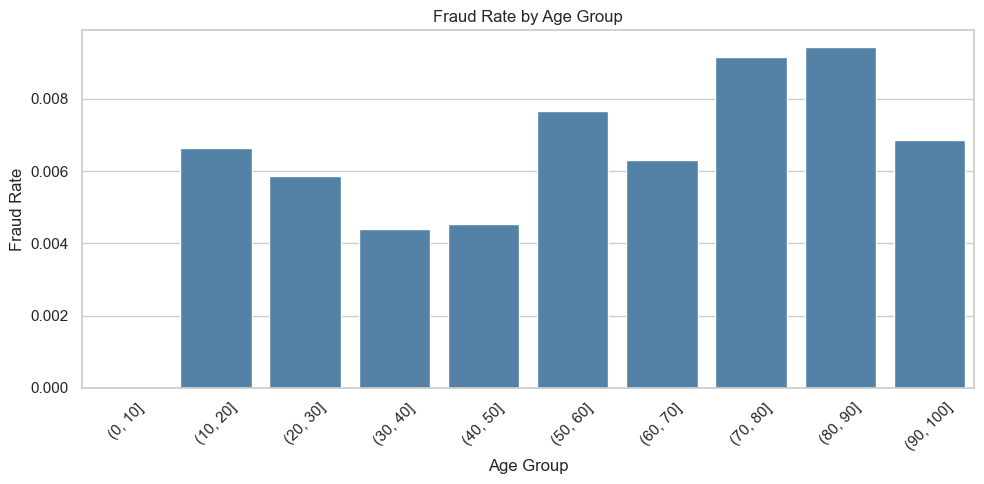

In [9]:
card_fraud_age = (
    card_fraud
    .assign(
        dob=lambda df: df["dob"].dt.tz_localize("UTC"),  # make dob UTC-aware
        age=lambda df: (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25,
        age_group=lambda df: pd.cut(df["age"], bins=range(0, 110, 10))
    )
)

fraud_by_age = (
    card_fraud_age
    .groupby("age_group", observed=True)["is_fraud"]
    .mean()
    .reset_index(name="fraud_rate")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=fraud_by_age, x="age_group", y="fraud_rate", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Fraud Rate")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Is fraud related to distance?

Calculate the distance between cardholder's home and the transaction location using the Haversine formula, then visualise the relationship with fraud.

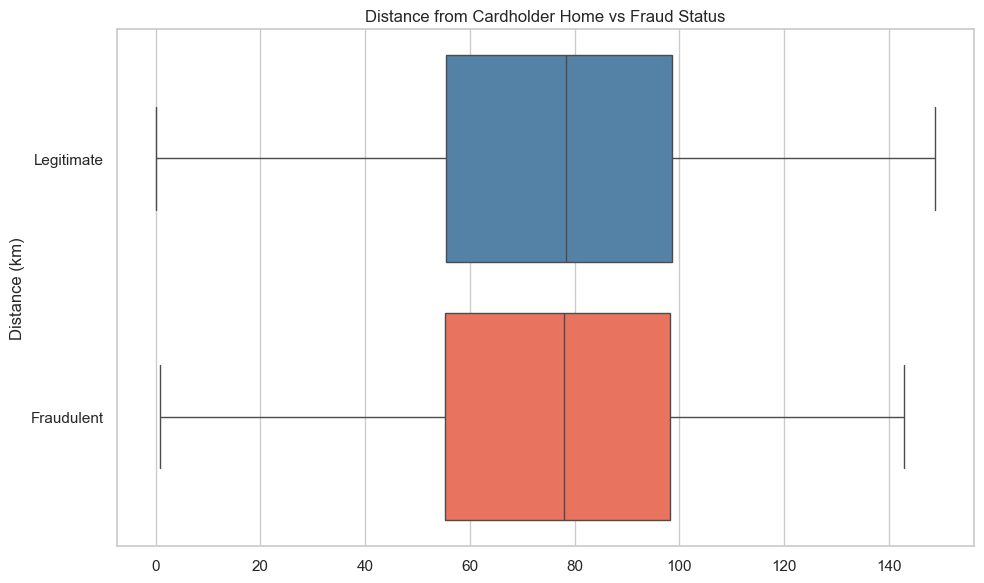

In [12]:
card_fraud_dist = (
    card_fraud
    .assign(
        lat1_rad=lambda df: np.radians(df["lat"]),
        lat2_rad=lambda df: np.radians(df["merch_lat"]),
        long1_rad=lambda df: np.radians(df["long"]),
        long2_rad=lambda df: np.radians(df["merch_long"]),
    )
    .assign(
        distance_km=lambda df: 6377.830272 * np.arccos(
            np.clip(
                np.sin(df["lat1_rad"]) * np.sin(df["lat2_rad"]) +
                np.cos(df["lat1_rad"]) * np.cos(df["lat2_rad"]) *
                np.cos(df["long2_rad"] - df["long1_rad"]),
                -1, 1
            )
        ),
        fraud_label=lambda df: df["is_fraud"].map({0: "Legitimate", 1: "Fraudulent"})
    )
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=card_fraud_dist, 
    x="distance_km", 
    y="fraud_label", 
    ax=ax,
    palette={"Legitimate": "steelblue", "Fraudulent": "tomato"})

ax.set_title("Distance from Cardholder Home vs Fraud Status")
ax.set_xlabel("")
ax.set_ylabel("Distance (km)")
plt.tight_layout()
plt.show()

**Interpretation:** If fraudulent transactions show a noticeably higher median distance or wider spread compared to legitimate ones, distance could be a useful feature for fraud detection. Examine the boxplot above to draw your conclusion.

## EDA Questions

- What did you learn from the EDA? If you were to build a classifier to predict credit card fraud, waht do you think would be the main drivers of fraud?
- What is the dollar cost of not having a fraud prevention programme?
- What is a false positive and what is a false negative and waht is the associated 'cost' for each of them? Which one should you care about?
- How would you build an interactive app that would flag transactions as fraudulent?



# Exploring sources of electricity production, CO2 emissions, and GDP per capita

We will get energy data from Our World in Data, and CO2 and GDP per capita from the World Bank using the `wbgapi` package.

## Load and Prepare Data

In [ ]:
# --- Define Global Color Palette ---
# This dictionary is a central hub for styling. By defining it here, we ensure
# that every chart uses the same consistent, thematic color for each fuel source.
fuel_color_palette = {
    # Fossil Fuels
    'coal': '#A0522D',      # Brown (Sienna)
    'oil': '#36454F',       # Dark Grey (Charcoal)
    'gas': '#6B9BD1',       # Soft Blue (like a natural gas flame)

    # Renewables
    'hydro': '#0077BE',     # Deep Blue (water)
    'solar': '#FFA500',     # Orange (sun, more distinct than yellow)
    'wind': '#A8D5E2',      # Light Sky Blue (air/sky)
    'biofuel': '#556B2F',    # Dark Green (biomass)
    'other_renewable': '#20B2AA', # Teal (general renewable)

    # Other
    'nuclear': '#E91E63'    # Pink/Magenta (a distinct, high-energy color)
}

# # ===========================================================================
# # 2. DATA LOADING: FETCH RAW DATA FROM ONLINE SOURCES
# # ===========================================================================

# # --- Load CO2 Data from Our World in Data (OWID) ---
# co2_df = ( 
#     pd.read_csv("https://ourworldindata.org/grapher/co-emissions-per-capita.csv?v=1&csvType=full&useColumnShortNames=true")
#     .clean_names()
#     .rename(columns={'emissions_total_per_capita': 'co2_per_capita', 'entity': 'country', 'code': 'iso_code'})
#     .query("year >= 1990")
# )

# # --- Load Energy Data from OWID ---
# energy_df = (
#     pd.read_csv("https://nyc3.digitaloceanspaces.com/owid-public/data/energy/owid-energy-data.csv")
#     .clean_names()
#     .query("year >= 1990")
#     .dropna(subset=['iso_code'])
#     .rename(columns={ # We rename the long electricity source columns to be short and simple
#         'biofuel_electricity': 'biofuel', 'coal_electricity': 'coal', 'gas_electricity': 'gas',
#         'hydro_electricity': 'hydro', 'nuclear_electricity': 'nuclear', 'oil_electricity': 'oil',
#         'other_renewable_exc_biofuel_electricity': 'other_renewable',
#         'solar_electricity': 'solar', 'wind_electricity': 'wind'
#     })
# )
# # --- Load GDP Data from World Bank API ---
# # We fetch GDP per capita, PPP (constant 2021 international $).
# indicator_id = 'NY.GDP.PCAP.PP.KD'
# gdp_percap_df = wb.data.DataFrame(
#     indicator_id,
#     time=range(1990, 2024),
#     skipBlanks=True,
#     columns='series'
# )
# # The API returns a multi-index; we reset it to get 'economy' and 'time' as columns.
# gdp_percap_df = gdp_percap_df.reset_index().rename(columns={
#     'economy': 'iso_code',
#     'time': 'year',
#     indicator_id: 'GDPpercap'
# })
# # The 'year' column comes as 'YR2021', so we remove 'YR' and convert to an integer.
# gdp_percap_df['year'] = gdp_percap_df['year'].str.replace('YR', '', regex=False).astype(int)


# # ===========================================================================
# # 3. DATA PREPARATION: TRANSFORM AND MERGE DATASETS
# # ===========================================================================

# # --- Create a "Tidy" Long-Format Energy DataFrame ---
# # The original energy_df is "wide" (one column for each fuel). For plotting with
# # libraries like Seaborn or for easy filtering, a "long" format (one column for
# # 'source', one for 'value') is much better. This is a key step in data wrangling.
# energy_long_df = (
#     energy_df
#     # Select only the columns we need for this transformation
#     .filter(items=[
#         'country', 'year', 'iso_code', 'population', 'gdp', 'biofuel', 'coal',
#         'gas', 'hydro', 'nuclear', 'oil', 'other_renewable', 'solar', 'wind'
#     ])
#     # The .melt() function transforms the DataFrame from wide format to long format.
#     .melt(
#         id_vars=['country', 'year', 'iso_code', 'population', 'gdp'],
#         var_name='source',
#         value_name='value'
#     )
#     .dropna(subset=['value', 'iso_code'])
# )

# # --- Create the Main Combined DataFrame for Analysis ---
# # Here we merge all three data sources into a single, comprehensive DataFrame.
# # We perform a series of "inner" merges, which means we only keep rows (country-year pairs)
# # that exist in ALL datasets, ensuring our final data is complete.

# # Merge 1: Energy data with GDP data. We join on the reliable 'iso_code' and 'year'.
# # We must select columns carefully to avoid duplicates like 'country_x', 'country_y'.
# merged_df = pd.merge(
#     energy_df,
#     gdp_percap_df,
#     on=['iso_code', 'year'],
#     how='inner'
# )
# # Merge 2: The result with CO2 data.
# combined_df = pd.merge(
#     merged_df,
#     co2_df.drop(columns=['country']), # Drop co2's country name to avoid conflicts
#     on=['iso_code', 'year'],
#     how='inner'
# )

# # --- Add Geographic Information ---
# # The country_converter library can add continent data based on country names,
# # which is useful for grouping or faceting plots later.
# combined_df['continent'] = coco.convert(names=combined_df['country'], to='continent', not_found=None)


combined_df = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/combined_df.csv")
energy_long_df = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/energy_long_df.csv")




In [ ]:
combined_df.head()


In [5]:

# ===========================================================================
# 4. VISUALIZATION FUNCTIONS: DEFINE REUSABLE PLOTTING LOGIC
# ===========================================================================

def plot_electricity_mix(country_name):
    """
    Plots a polished, themed 100% stacked area chart of the electricity mix for one country.

    This function incorporates several best practices:
    - Stacks the largest sources at the bottom for readability.
    - Uses the centrally defined `fuel_color_palette` for color consistency.
    - Removes all axis padding for a clean, modern look.
    - Reverses the legend order to match the visual stacking order.
    """
    print(f"\n--- Generating electricity mix plot for {country_name}... ---")

    country_energy_df = energy_long_df.query(f"country == '{country_name}'")
    if country_energy_df.empty:
        print(f"--> No data available for {country_name}.")
        return

    # Pivot the data to get years as rows and fuel sources as columns.
    pivot_df = country_energy_df.pivot_table(index='year', columns='source', values='value', aggfunc='sum')
    # KEY TRICK 1: Determine stacking order based on max contribution.
    source_order = pivot_df.max().sort_values(ascending=False).index
    pivot_df = pivot_df[source_order] # Reorder columns based on this.

    # Convert raw values to percentages.
    pivot_df_percentage = pivot_df.divide(pivot_df.sum(axis=1), axis=0).fillna(0)

    # KEY TRICK 2: Create a color list that matches the new column order.
    ordered_colors = [fuel_color_palette.get(source, '#CCCCCC') for source in source_order]

    fig, ax = plt.subplots(figsize=(12, 7))
    pivot_df_percentage.plot.area(
        ax=ax, stacked=True, alpha=0.9, linewidth=0.5,
        legend=False, # We will create a custom legend later.
        color=ordered_colors
    )

    # --- Polish the Plot ---
    ax.set_title(f"Electricity Production Mix (%) for {country_name}", fontsize=16)
    ax.set_ylabel("Share of Total Electricity Production")
    ax.set_xlabel(None) # Remove "Year" for a cleaner look.
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.margins(x=0, y=0) # Remove all padding from axes.
    ax.set_ylim(0, 1)   # Set y-axis to be exactly 0-100%.

    # KEY TRICK: Reverse the legend to match the stacking order (top-to-bottom).
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles[::-1], labels=labels[::-1], title='Source',
        bbox_to_anchor=(1.05, 1), loc='upper left'
    )
    plt.tight_layout()
    plt.show()


def top_fuel(source, year, n):
    """
    Plots a themed horizontal bar chart of the top N producers for a given fuel.
    """
    print(f"\n--- Generating Top {n} plot for {source} in {year}... ---")

    top_producers = (
        energy_long_df
        .query(f"source == '{source}' and year == {year}")
        .nlargest(n, 'value')
        # Sort ascending so the largest bar will be at the top of the plot.
        .sort_values('value', ascending=True)
    )
    # Get the specific color for this fuel source from our palette.
    bar_color = fuel_color_palette.get(source, '#CCCCCC')

    fig, ax = plt.subplots(figsize=(10, 8))

    # --- STEP 1: Create the bars and capture the container object ---
    bars = ax.barh(top_producers['country'], top_producers['value'], color=bar_color)
    ax.set_title(f"Top {n} {source.capitalize()} Producing Countries in {year} in TWh", fontsize=16)
    ax.set_xlabel("Electricity Produced (Terawatt-hours)")
    ax.set_ylabel(None)

    # Use ax.bar_label() to add labels to the container ---
    # This single line replaces the entire for loop.
    ax.bar_label(
        bars,
        fmt='%.1f',          # Format the label to one decimal place
        padding=5,          # Positive padding pushes the text to the right (outside the bar)
        color="#0E0E0E",       # Text color
        fontsize=10,         # Font size
        fontweight='bold'    # Font weight
    )
    
    # Adjust the x-axis limit to make sure the labels are always visible
    # This adds a little space to the right of the longest bar.
    ax.set_xlim(right=ax.get_xlim()[1] * 1.05)



    plt.tight_layout()
    plt.show()


def electricity_mix_co2_gdp(country):
    """
    Generates a 3-panel dashboard: the polished electricity mix chart on top,
    and two scatter plots below showing the country's trajectory over time.
    """
    print(f"\n--- Generating 3-plot dashboard for {country}... ---")

    # Use GridSpec for a more complex layout (a tall plot on top, two smaller below).
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=(2, 1.5))
    ax1 = fig.add_subplot(gs[0, :]) # Top plot spans both columns.
    ax2 = fig.add_subplot(gs[1, 0]) # Bottom-left plot.
    ax3 = fig.add_subplot(gs[1, 1]) # Bottom-right plot.

    fig.suptitle(f"Comprehensive Energy & Emissions Analysis: {country}", fontsize=20)

    # --- Plot 1: Electricity Production Mix (Reusing the same polished logic) ---
    country_energy_df = energy_long_df.query(f"country == '{country}' and year >= 2000")
    if country_energy_df.empty:
        print(f"--> No energy data for {country} to create dashboard.")
        plt.close(fig)
        return

    pivot_df = country_energy_df.pivot_table(index='year', columns='source', values='value', aggfunc='sum')
    source_order = pivot_df.max().sort_values(ascending=False).index
    pivot_df = pivot_df[source_order]
    pivot_df_percentage = pivot_df.divide(pivot_df.sum(axis=1), axis=0).fillna(0)
    ordered_colors = [fuel_color_palette.get(source, '#CCCCCC') for source in source_order]

    pivot_df_percentage.plot.area(ax=ax1, stacked=True, alpha=0.9, linewidth=0.5, legend=False, color=ordered_colors)
    ax1.set_title("Electricity Production Mix (%) since 2000", fontsize=14)
    ax1.set_ylabel("Share of Production")
    ax1.set_xlabel(None)
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax1.margins(x=0, y=0)
    ax1.set_ylim(0, 1)
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles=handles[::-1], labels=labels[::-1], title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')

    # --- Filter data for the scatter plots ---
    country_data = combined_df.query(f"country == '{country}' and year >= 2000").copy()
    if country_data.empty:
        print(f"--> No combined CO2/GDP data for {country}, cannot create scatter plots.")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        return

    # --- Plot 2: CO2 vs GDP per capita ---
    sns.scatterplot(data=country_data, x='GDPpercap', y='co2_per_capita', ax=ax2, s=50)
    ax2.set_title("CO2 vs. GDP per Capita", fontsize=14)
    ax2.set_xlabel("GDP per capita (constant 2021 intl $)")
    ax2.set_ylabel("CO2 emissions per capita (tonnes)")
    for i, row in country_data.iterrows():
        ax2.text(row['GDPpercap'], row['co2_per_capita'], str(row['year']), fontsize=7)

    # --- Plot 3: CO2 emissions vs. electricity consumption ---
    country_data['daily_kwh'] = country_data['per_capita_electricity'] / 365
    sns.scatterplot(data=country_data, x='daily_kwh', y='co2_per_capita', ax=ax3, s=50)
    ax3.set_title("CO2 Emissions vs. Electricity Consumption", fontsize=14)
    ax3.set_xlabel("Daily Electricity per Capita (kWh)")
    ax3.set_ylabel(None) # Y-axis is shared with the plot to its left.
    for i, row in country_data.iterrows():
        ax3.text(row['daily_kwh'], row['co2_per_capita'], str(row['year']), fontsize=7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## 1. Stacked area chart: Electricity generation by source for your country since 2000




--- Generating electricity mix plot for United Kingdom... ---


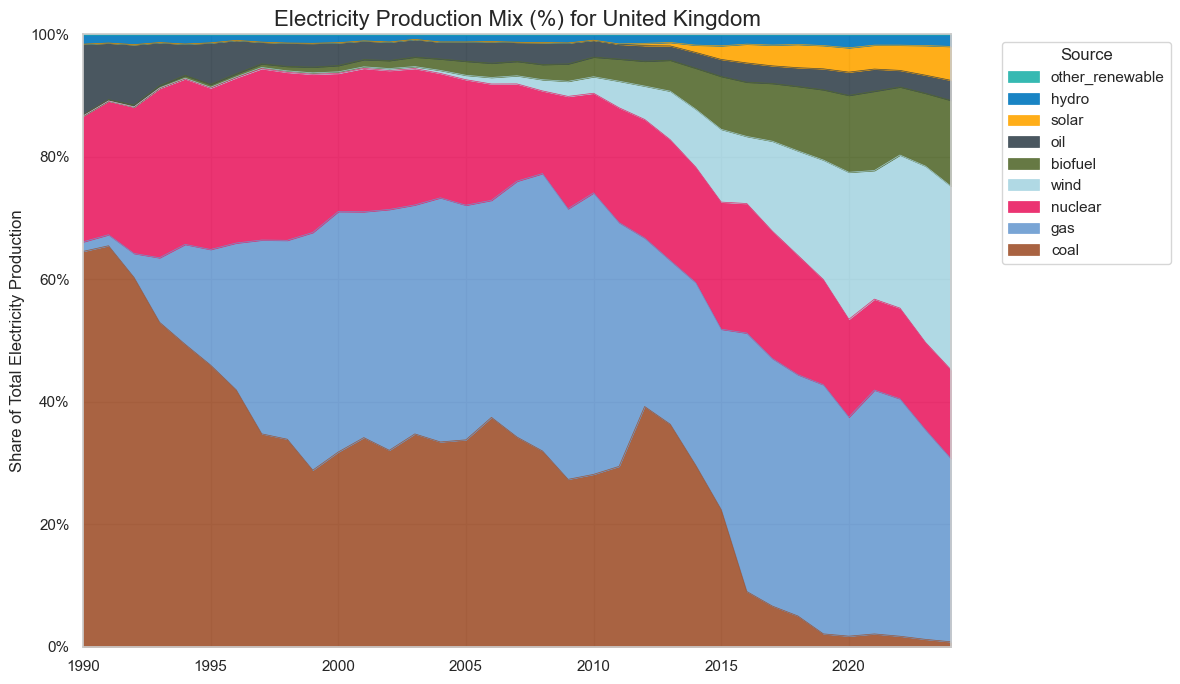


--- Generating electricity mix plot for Greece... ---


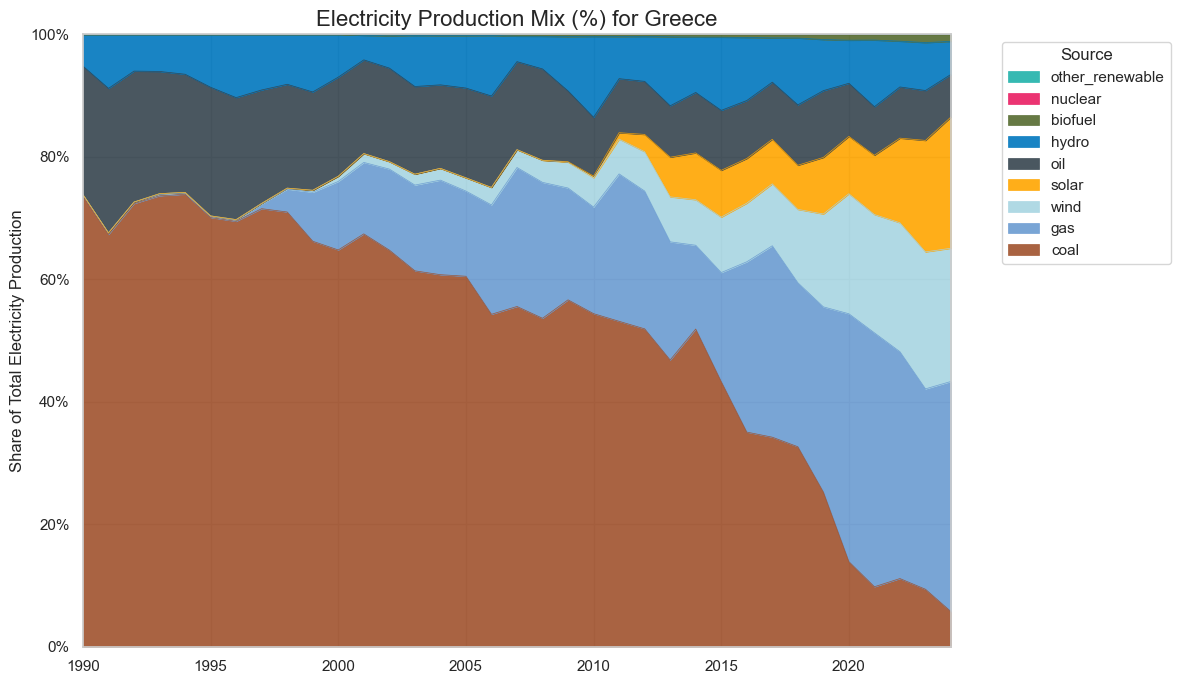

In [ ]:
MY_COUNTRY = "United Kingdom"  # <-- Change this to your country
plot_electricity_mix(MY_COUNTRY)

plot_electricity_mix("Greece")

## 2. Top N fuel (Coal, solar, wind) sources for electricity generation for a specific year around thw world-- data is up to 2024


--- Generating Top 10 plot for coal in 2024... ---


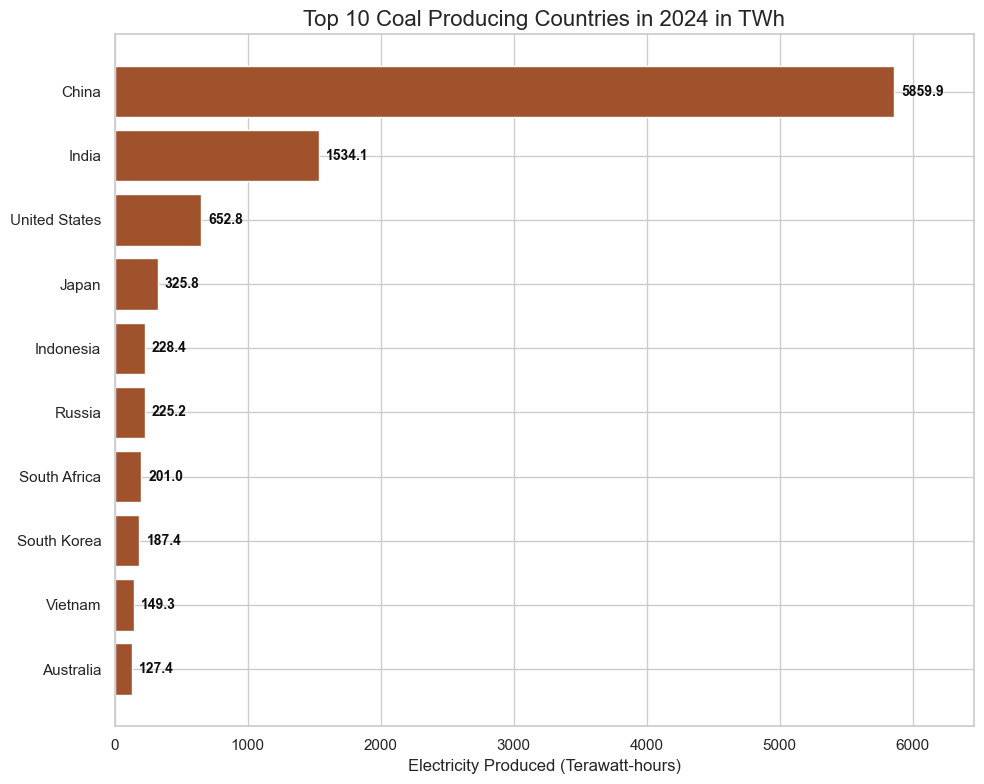


--- Generating Top 10 plot for solar in 2024... ---


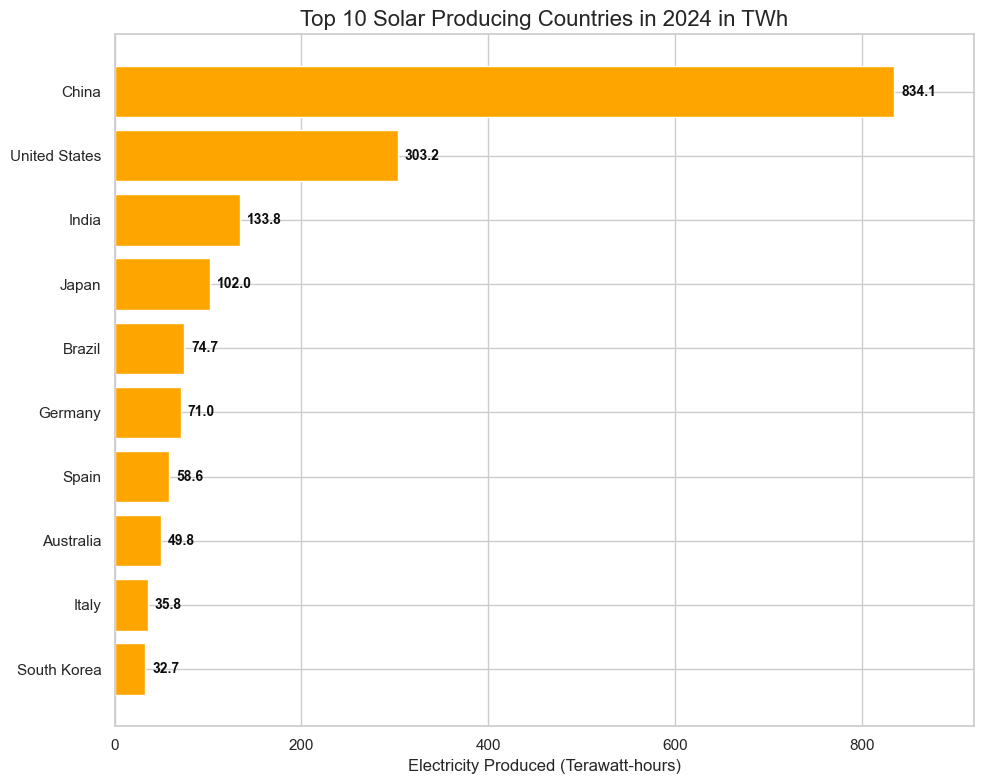


--- Generating Top 10 plot for wind in 2024... ---


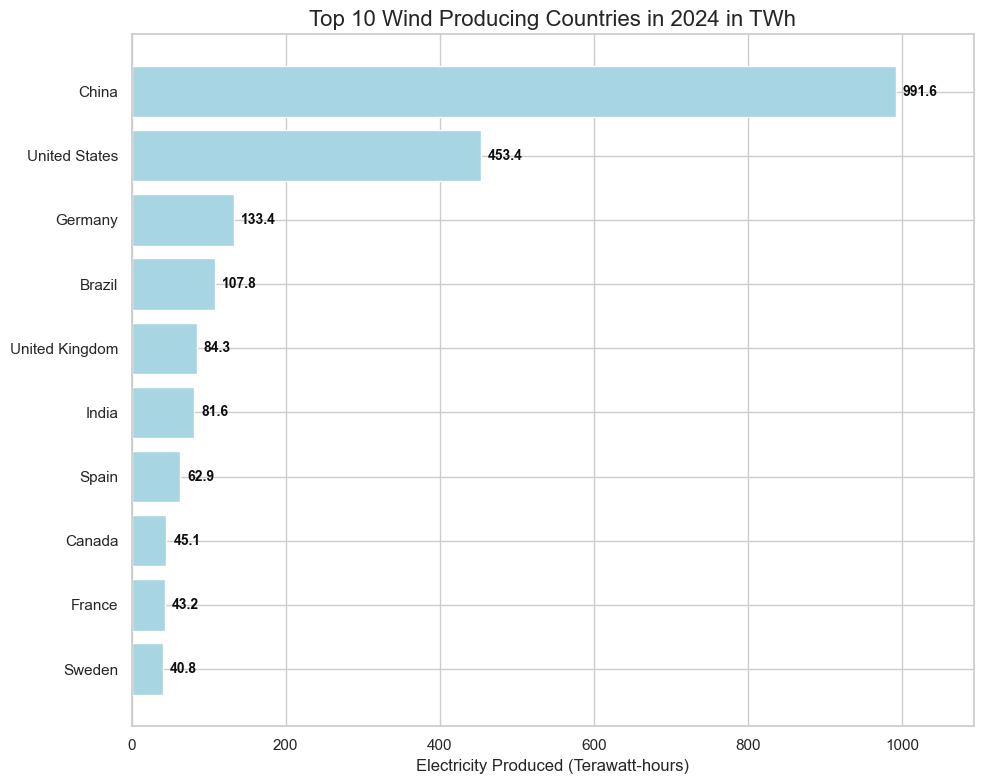

In [15]:
## 2. Top N fuel sources for a specific year around thw world-- data is up to 2024

top_fuel("coal", 2024, 10)
top_fuel("solar", 2024, 10)
top_fuel("wind", 2024, 10)


## 23. Scatter plot: Electricity generation, CO2 per capita vs GDP per capita, CO2 per capita vs kwH per capita for a target country


--- Generating 3-plot dashboard for China... ---


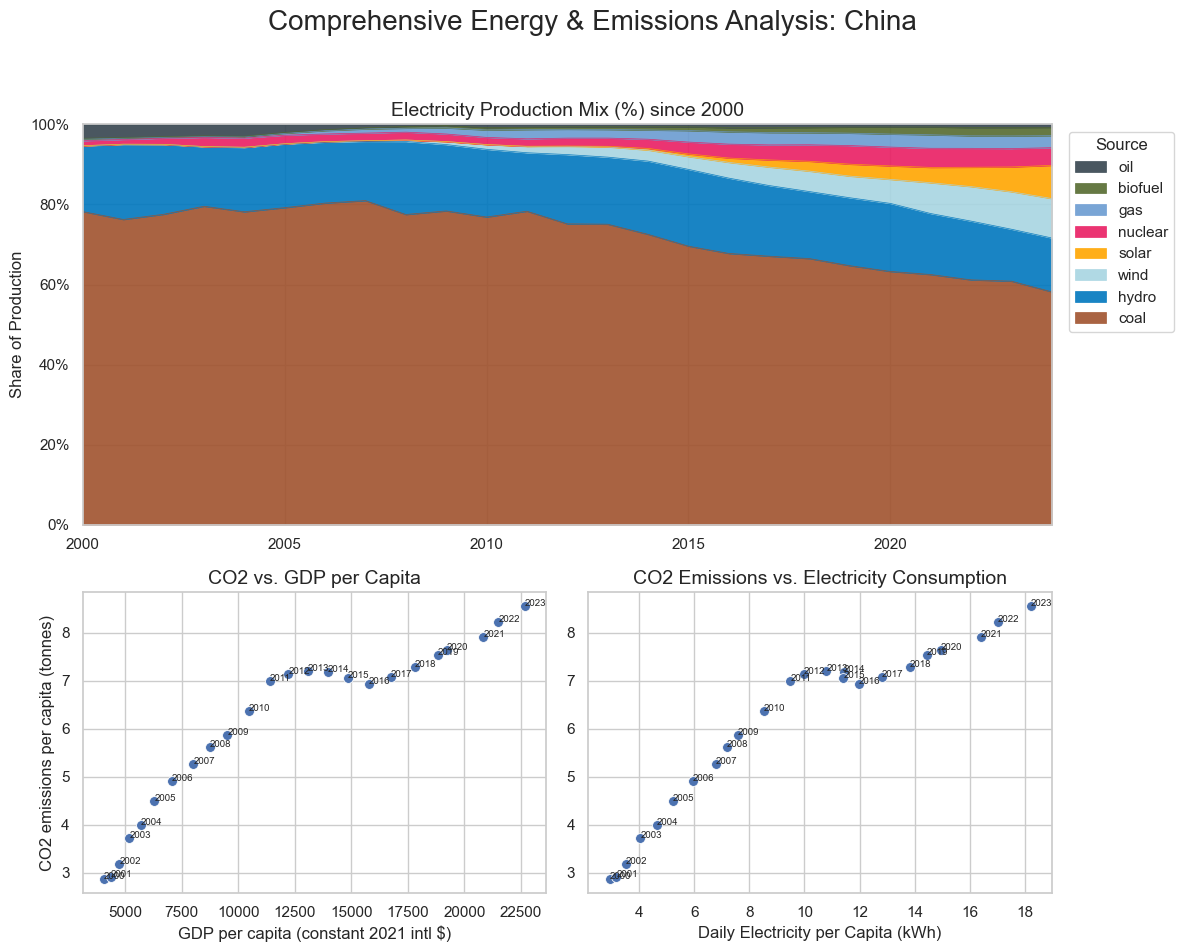


--- Generating 3-plot dashboard for Chile... ---


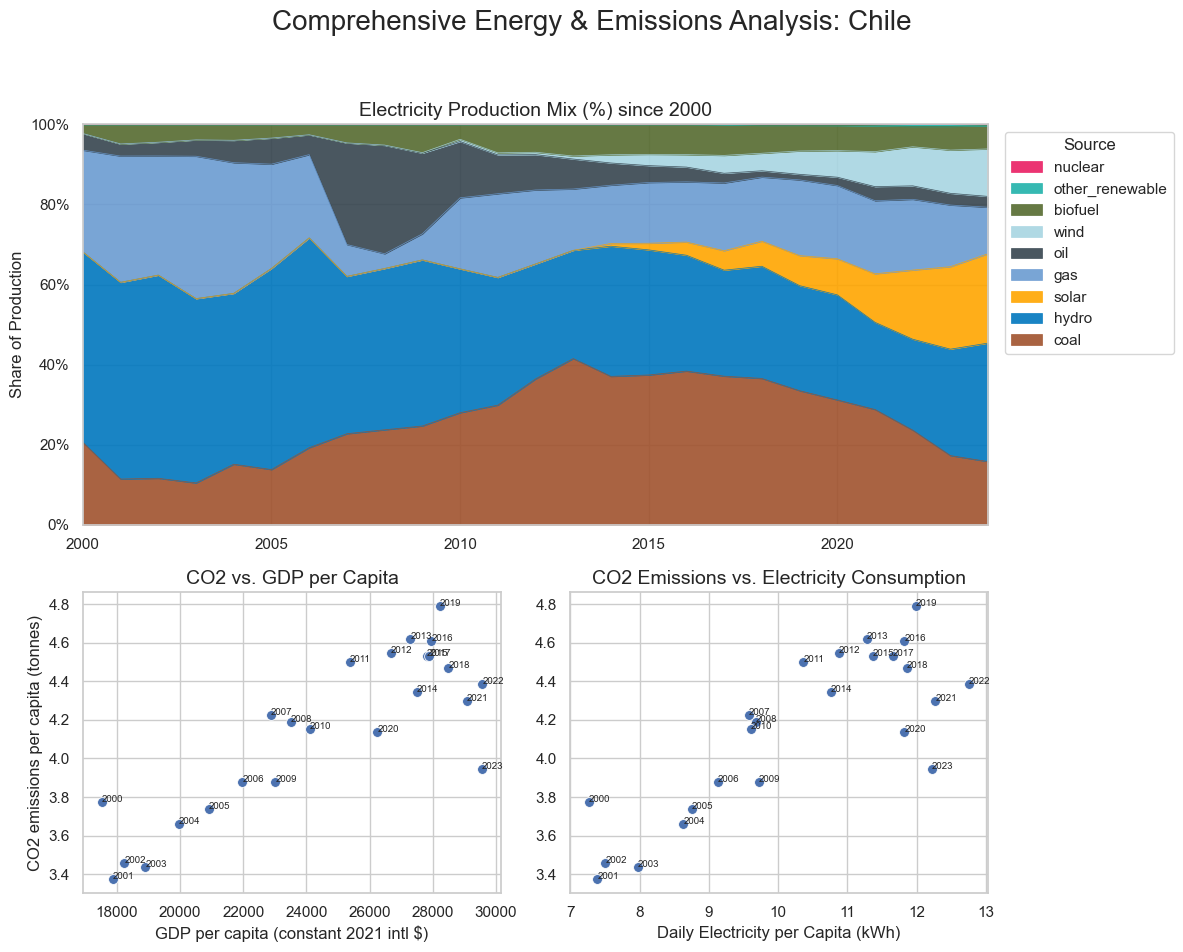


--- Generating 3-plot dashboard for Germany... ---


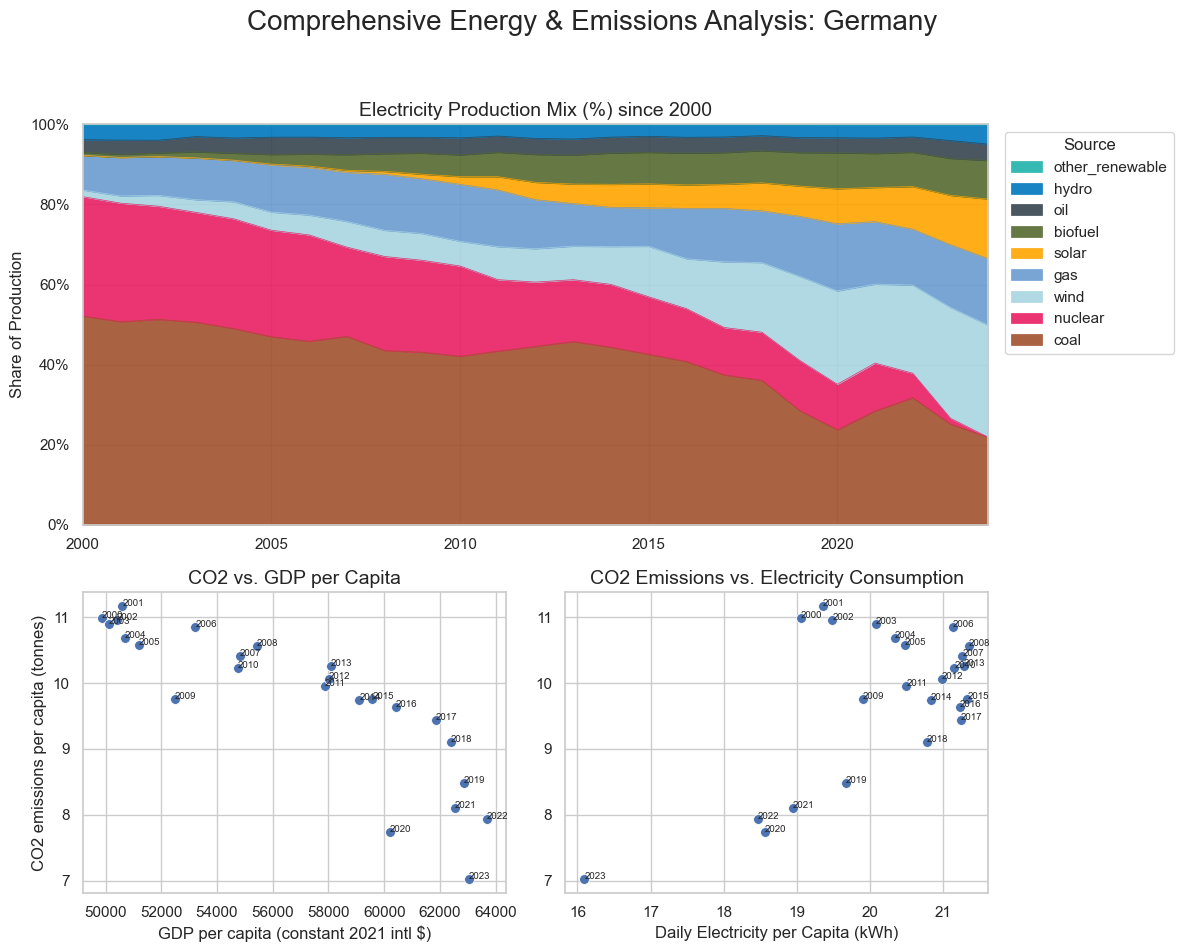

In [26]:
electricity_mix_co2_gdp("China")
electricity_mix_co2_gdp("Chile")
electricity_mix_co2_gdp("Germany")

## Energy, Emissions, GDP Questions

- What did you learn from the EDA? 
- Which countries have decoupled GDP growth from emissions? 
- How does electricity usage (per capita/per day) vary around the world? 
- Is electtricity electricity usage (per capita/per day) a good predictor of CO2/per cap? Look at countries with a population > 30m
